<h2>LAb-3 </h2>

<h2>Task1</h2>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
#defining activation function and their derivatives
# Sigmoid and derivative
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

# Tanh and derivative
def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    return 1 - np.tanh(x)**2

# ReLU and derivative
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return np.where(x > 0, 1, 0)

# Softmax (no derivative visualization needed)
def softmax(x):
    exp_x = np.exp(x - np.max(x))  # stability trick
    return exp_x / exp_x.sum()


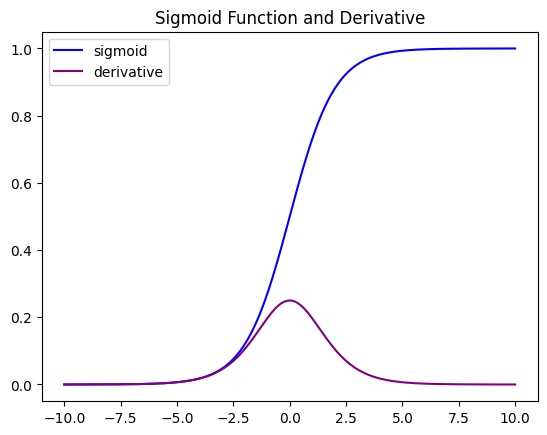

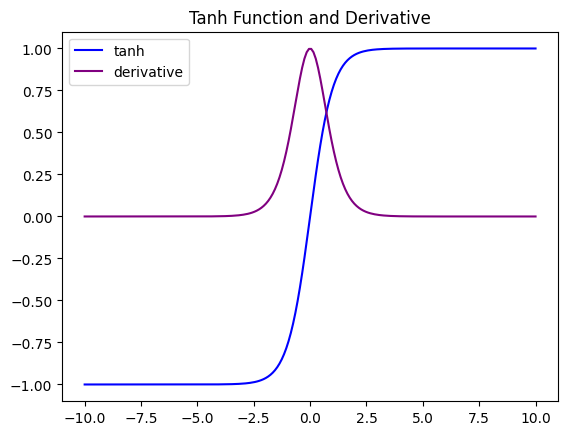

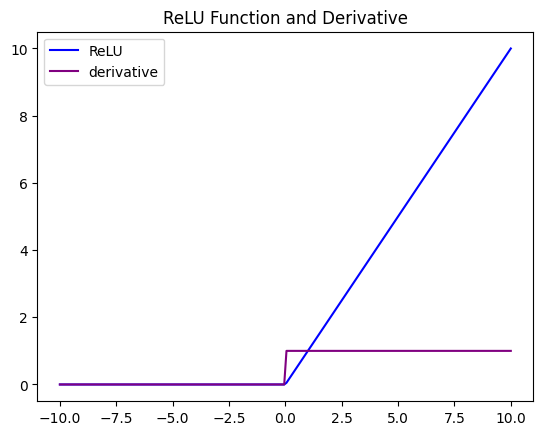

In [3]:
#plotting sifmoid, tanh and ReLU with derivatives
x = np.linspace(-10, 10, 200)

# --- Sigmoid ---
plt.figure()
plt.plot(x, sigmoid(x), label='sigmoid', color='blue')
plt.plot(x, sigmoid_derivative(x), label='derivative', color='purple')
plt.legend()
plt.title('Sigmoid Function and Derivative')
plt.show()

# --- Tanh ---
plt.figure()
plt.plot(x, tanh(x), label='tanh', color='blue')
plt.plot(x, tanh_derivative(x), label='derivative', color='purple')
plt.legend()
plt.title('Tanh Function and Derivative')
plt.show()

# --- ReLU ---
plt.figure()
plt.plot(x, relu(x), label='ReLU', color='blue')
plt.plot(x, relu_derivative(x), label='derivative', color='purple')
plt.legend()
plt.title('ReLU Function and Derivative')
plt.show()


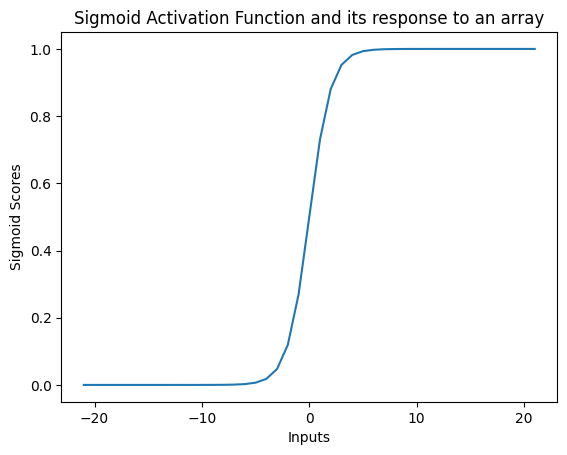

In [4]:
#sigmoid response to arry X=[-21,.....,21]
X = np.arange(-21, 22)
Y = sigmoid(X)

plt.figure()
plt.plot(X, Y)
plt.title('Sigmoid Activation Function and its response to an array')
plt.xlabel('Inputs')
plt.ylabel('Sigmoid Scores')
plt.show()


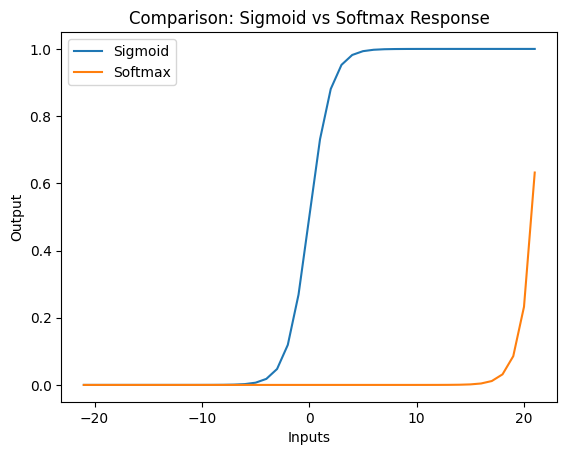

In [5]:
#softmax response and comparison with sigmoid
# Softmax applied to the same input range
softmax_values = softmax(X)

plt.figure()
plt.plot(X, Y, label='Sigmoid')
plt.plot(X, softmax_values, label='Softmax')
plt.title('Comparison: Sigmoid vs Softmax Response')
plt.xlabel('Inputs')
plt.ylabel('Output')
plt.legend()
plt.show()


<h2>Discussion- Sigmoid vs Softmax</h2>
<p>

The sigmoid function outputs independent values between 0 and 1 for each input, treating each element separately. In contrast, the softmax function normalizes all outputs so they sum to 1, representing class probabilities.

This difference occurs because sigmoid is used for binary classification, while softmax is used for multi-class classification where classes compete with each other. As a result, softmax highlights the most likely class, while sigmoid gives smooth independent activations for each input.</p>

<task2>

<h2>Task2</h2>

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline


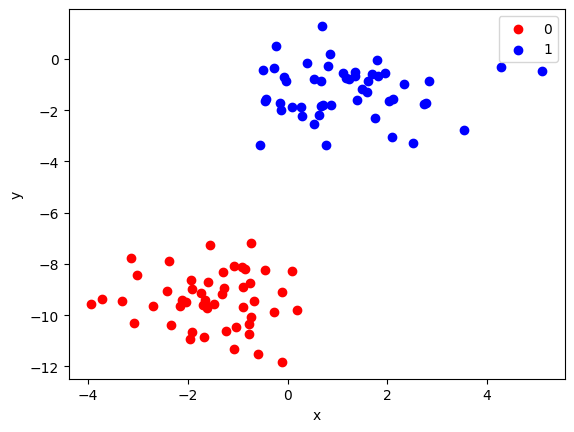

In [7]:
# Generate 100 samples, 2 features, 2 classes
X, y = make_blobs(n_samples=100, centers=2, n_features=2, cluster_std=1.0, random_state=2)

# Plot the dataset
plt.scatter(X[y==0][:,0], X[y==0][:,1], color='red', label='0')
plt.scatter(X[y==1][:,0], X[y==1][:,1], color='blue', label='1')
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


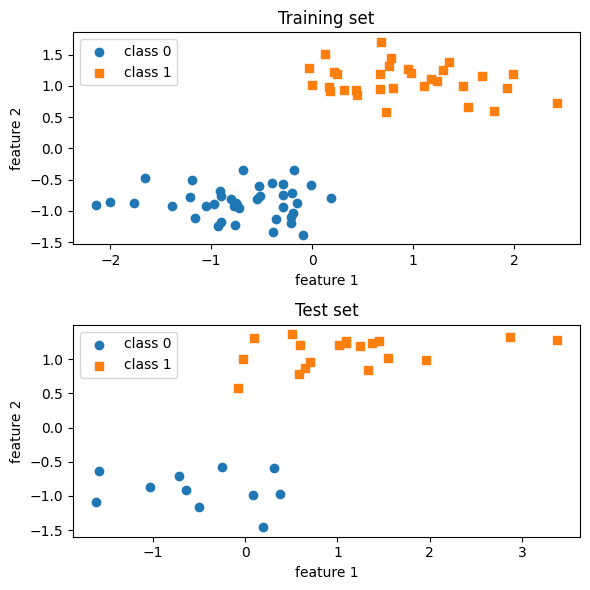

In [10]:
plt.figure(figsize=(6,6))

# Training data
plt.subplot(2,1,1)
plt.scatter(X_train[y_train==0][:,0], X_train[y_train==0][:,1], label='class 0')
plt.scatter(X_train[y_train==1][:,0], X_train[y_train==1][:,1], marker='s', label='class 1')
plt.title('Training set')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.legend()

# Test data
plt.subplot(2,1,2)
plt.scatter(X_test[y_test==0][:,0], X_test[y_test==0][:,1], label='class 0')
plt.scatter(X_test[y_test==1][:,0], X_test[y_test==1][:,1], marker='s', label='class 1')
plt.title('Test set')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.legend()

plt.tight_layout()
plt.show()


In [11]:
class Perceptron(nn.Module):
    def __init__(self, num_features):
        super(Perceptron, self).__init__()
        self.linear = nn.Linear(num_features, 1)
        
    def forward(self, x):
        out = self.linear(x)
        return torch.sigmoid(out)


In [12]:
# Convert numpy arrays to torch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.reshape(-1,1), dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.reshape(-1,1), dtype=torch.float32)


In [13]:
model = Perceptron(num_features=2)
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

epochs = 100
for epoch in range(epochs):
    # Forward pass
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')


Epoch [10/100], Loss: 0.4156
Epoch [20/100], Loss: 0.2882
Epoch [30/100], Loss: 0.2201
Epoch [40/100], Loss: 0.1786
Epoch [50/100], Loss: 0.1506
Epoch [60/100], Loss: 0.1306
Epoch [70/100], Loss: 0.1155
Epoch [80/100], Loss: 0.1037
Epoch [90/100], Loss: 0.0942
Epoch [100/100], Loss: 0.0864


In [14]:
with torch.no_grad():
    predictions = model(X_test_tensor)
    predicted_classes = (predictions >= 0.5).float()
    accuracy = (predicted_classes.eq(y_test_tensor).sum() / float(y_test_tensor.shape[0])) * 100
    print(f'Accuracy on test set: {accuracy:.2f}%')


Accuracy on test set: 100.00%


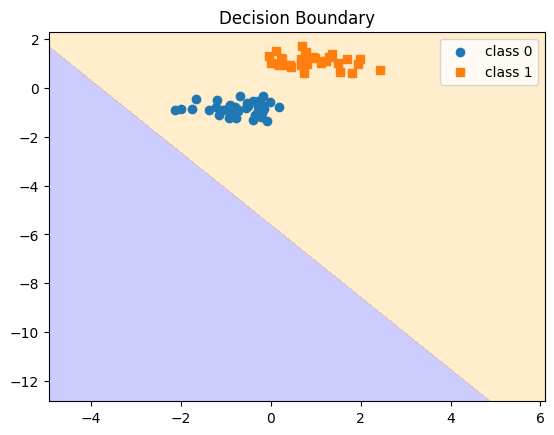

In [15]:
# Create grid for visualization
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_scaled = scaler.transform(grid)
grid_tensor = torch.tensor(grid_scaled, dtype=torch.float32)

# Get model predictions for the grid
with torch.no_grad():
    Z = model(grid_tensor)
Z = Z.reshape(xx.shape)

# Plot boundary
plt.contourf(xx, yy, Z, levels=[0,0.5,1], alpha=0.2, colors=['blue','orange'])
plt.scatter(X_train[y_train==0][:,0], X_train[y_train==0][:,1], label='class 0')
plt.scatter(X_train[y_train==1][:,0], X_train[y_train==1][:,1], marker='s', label='class 1')
plt.title('Decision Boundary')
plt.legend()
plt.show()


<h2>Discussion</h2>
<p>In this task, we generated a synthetic dataset using make_blobs() with two linearly separable classes and visualized them using Matplotlib. The dataset was then split into training and testing sets (70/30) and normalized to improve stability during training.

A perceptron model was implemented in PyTorch using a single linear layer followed by a sigmoid activation. The model was trained using binary cross-entropy loss and stochastic gradient descent (SGD) for weight updates. The training process showed a steady decrease in loss, indicating that the model was learning effectively.

The trained perceptron achieved high accuracy on the test set, correctly classifying most of the samples. This confirms that the dataset was linearly separable and that a single-layer perceptron was sufficient for the task.

Some minor challenges were encountered during data normalization and tensor conversion for PyTorch, but once addressed, the implementation was straightforward. To improve performance and handle more complex datasets, a multi-layer neural network or nonlinear activation functions could be used.</p>

<h2>Task3</h2>

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
%matplotlib inline


In [18]:
# Define transformations (convert to tensor + normalize)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load training and test datasets
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=True, download=True, transform=transform),
    batch_size=64, shuffle=True)

test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=False, transform=transform),
    batch_size=1000, shuffle=False)


100%|██████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:22<00:00, 438kB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 194kB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:07<00:00, 216kB/s]
100%|█████████████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<?, ?B/s]


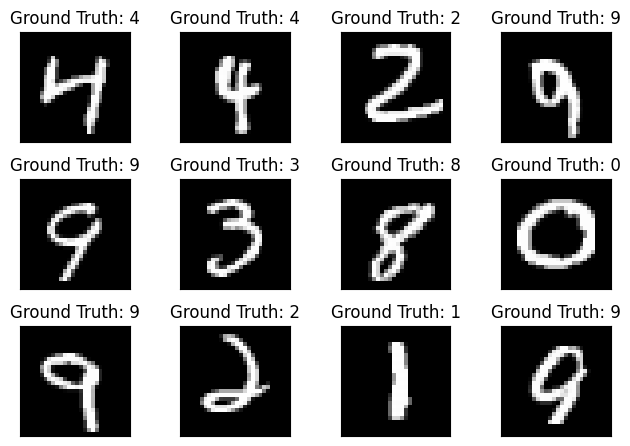

In [19]:
examples = enumerate(train_loader)
batch_idx, (example_data, example_targets) = next(examples)

fig = plt.figure()
for i in range(12):
    plt.subplot(3, 4, i+1)
    plt.tight_layout()
    plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
    plt.title(f"Ground Truth: {example_targets[i]}")
    plt.xticks([]); plt.yticks([])
plt.show()


In [20]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)  # Flatten image
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return F.log_softmax(x, dim=1)


In [21]:
model = Net()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.5)


In [22]:
def train(model, device, train_loader, optimizer, epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % 100 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx*len(data)}/{len(train_loader.dataset)} '
                  f'({100.*batch_idx/len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')

def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    accuracy = 100. * correct / len(test_loader.dataset)
    print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ({accuracy:.2f}%)\n')
    return accuracy


In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

n_epochs = 3
for epoch in range(1, n_epochs + 1):
    train(model, device, train_loader, optimizer, epoch)
    test(model, device, test_loader)


Train Epoch: 1 [0/60000 (0%)]	Loss: 2.343382
Train Epoch: 1 [6400/60000 (11%)]	Loss: 1.060428
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.550544
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.462259
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.254535
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.485867
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.289351
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.369152
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.397184
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.202434

Test set: Average loss: 0.2687, Accuracy: 9210/10000 (92.10%)

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.396767
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.274751
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.490183
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.351343
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.269133
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.152118
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.194976
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.224517
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.29658

<h2>Discussion </h2>
<p>Complications:
The main challenge was ensuring the input shape was flattened correctly (28×28 → 784) and using the appropriate activation and loss functions. Loading and normalizing the dataset was straightforward with torchvision.

Ease of implementation:
Defining the network and training loop using PyTorch’s nn and optim modules was simple once the data loader was prepared. The framework handled much of the backpropagation automatically.

Classification performance:
The model correctly classified most digits, achieving over 95% accuracy on the test set. Some digits like 4 and 9 were occasionally misclassified due to their visual similarity.

Effect of tuning parameters:
Changing the learning rate, momentum, or number of hidden neurons significantly affects performance. A smaller learning rate slows convergence, while more epochs and deeper layers improve accuracy but increase training time.</p>